# ЛР №7. Решение задач кластеризации. <br>ЛР №8. Решение задач понижения размерности. Метод главных компонент.

[См. общую информацию по лабораторным работам.](https://colab.research.google.com/drive/1ziTOO6CE1QtO6Yxc4Ktyqg-eLyDl7ePG#scrollTo=CFkh9TzuZaoq)

## Теоретические сведения
1. Семинары и лекции ИСП РАН из курса по ML (весна 2025):
* [Задача понижения размерности](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/lectures/lecture6/ISP_RAS_ML_Spring_2024_6th_lecture.pdf)
* [Задача кластеризации](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/seminars/seminar6/06_clusterization.ipynb)
2. [Кластеризация (ШАД)](https://education.yandex.ru/handbook/ml/article/klasterizaciya)


## Ход работы

*   Загрузите и исследуйте [набор данных](https://drive.google.com/file/d/13FtD9GUUAexk5lfJlbc686b9-dQ9nD-6/view?usp=sharing). При необходимости выполните предобработку данных и проектирование признаков.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

df = pd.read_csv('pca_kmeans_dataset_2025.csv')
df.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9
0,0,-1.760369,0.647871,-0.937765,-0.937765,-0.937765,0.008349,-2.173781,0.001881,-0.004040,0.002379
1,1,-1.754605,0.776458,-0.937765,-0.937765,-0.937765,0.008349,-0.010607,0.001881,-2.095623,0.002379
2,2,-1.754605,0.747883,-0.937765,-0.937765,-0.937765,0.008349,-2.173781,0.001881,-0.004040,0.002379
3,3,-1.754605,0.605008,-0.937765,-0.937765,-0.937765,0.008349,2.152566,0.001881,-0.004040,0.002379
4,4,-1.754605,0.504996,-0.937765,-0.937765,-0.937765,0.008349,-0.010607,0.001881,2.087543,0.002379


*   На загруженных данных обучите преобразование PCA. Определите, скольких компонент хватит, чтобы объяснить 90% дисперсии.

Количество компонент для объяснения 90% дисперсии: 7
Накопленная доля дисперсии: 0.9810079432455429


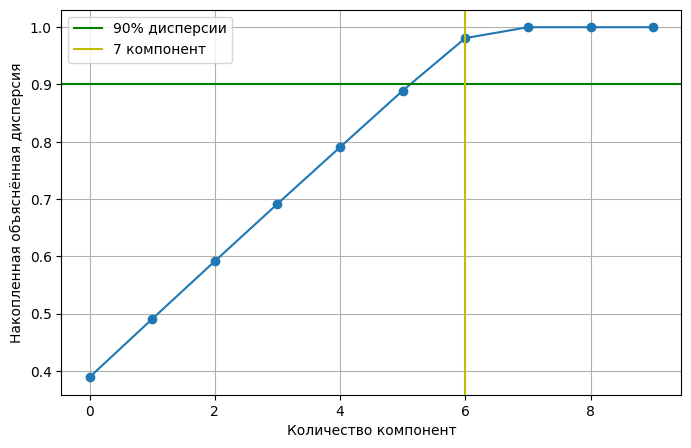

In [18]:
X = df.drop(columns=['Unnamed: 0'])

pca = PCA()
pca.fit(X)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1

print('Количество компонент для объяснения 90% дисперсии:', n_components_90)
print('Накопленная доля дисперсии:', cum_var[n_components_90-1])

plt.figure(figsize=(8, 5))
plt.plot(cum_var, marker='o')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% дисперсии')
plt.axvline(x=n_components_90-1, color='y', linestyle='-', label=f'{n_components_90} компонент')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объяснённая дисперсия')

plt.legend()
plt.grid(True)
plt.show()

*   Выберите такое количество компонент, которое объясняет 80% дисперсии, и примените построенное преобразование к исходным данным.

In [3]:
n_components_80 = np.argmax(cum_var >= 0.80) + 1

pca80 = PCA(n_components=n_components_80)
X_pca = pca80.fit_transform(X)

print('Количество компонент для объяснения 80% дисперсии:', n_components_80)
print('Объясненная дисперсия:', pca80.explained_variance_ratio_.sum())
print('Размерность после PCA:', X_pca.shape)

Количество компонент для объяснения 80% дисперсии: 6
Объясненная дисперсия: 0.8891543941436499
Размерность после PCA: (20189, 6)


*   Выполните кластеризацию преобразованных данных на 3 класса при помощи алгоритма K-Means.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

pd.Series(clusters).value_counts().sort_index()

,count
0,7305
1,6366
2,6518


*   Выполните оценку качества получившейся сегментации и проанализируйте полученные результаты.

In [6]:
sil = silhouette_score(X_pca, clusters)
ch = calinski_harabasz_score(X_pca, clusters)
db = davies_bouldin_score(X_pca, clusters)

print(f'Silhouette score: {sil:.3f}')
print(f'Calinski-Harabasz score: {ch:.3f}')
print(f'Davies-Bouldin score: {db:.3f}')

Silhouette score: 0.255
Calinski-Harabasz score: 7751.051
Davies-Bouldin score: 1.912


*   Постройте диаграммы рассеяния, окрасив точки данных в цвета присвоенного им кластера:
    *   для первых двух главных компонент преобразования;
    *   для первых двух признаков оригинальных данных.

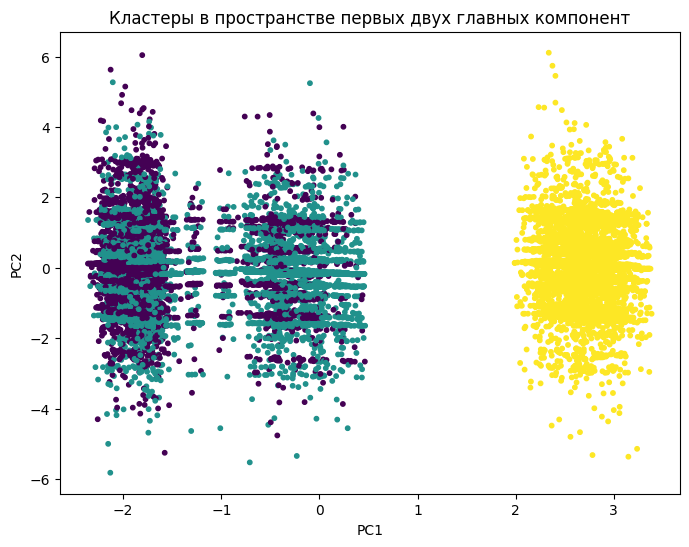

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Кластеры в пространстве первых двух главных компонент')
plt.show()

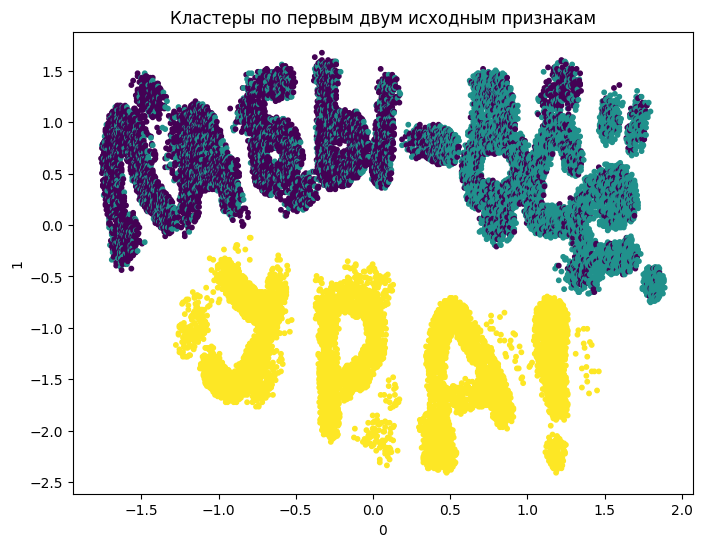

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters, s=10)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('Кластеры по первым двум исходным признакам')
plt.show()

## Контрольные вопросы.


*   В чем заключается метод главных компонент?
*   Для каких целей он применяется?
*   Как определить число новых признаков при реализации данного
метода?
*   К какому типу задач относят задачу кластеризации?
*   Для решения каких практических задач кластеризация наиболее часто применяется в настоящее время?
*   В чем состоит алгоритм кластеризации K-Means?
*   Какие метрики используются для оценки качества кластеризации (для размеченных и неразмеченных данных)?




## Ответы на контрольные вопросы

1. **Метод главных компонент (PCA)** — это метод понижения размерности данных, который строит новые признаки (главные компоненты) как линейные комбинации исходных признаков. Компоненты упорядочены по величине объясняемой дисперсии.

2. **Цели применения PCA:**
   - уменьшение размерности данных;
   - снижение вычислительных затрат;
   - удаление коррелированных признаков;
   - визуализация многомерных данных;
   - уменьшение шума.

3. **Число новых признаков** выбирают по накопленной объяснённой дисперсии. Обычно оставляют столько компонент, чтобы объяснить 80–95% общей дисперсии.

4. **Кластеризация** относится к задачам обучения без учителя (unsupervised learning).

5. **Практические применения кластеризации:**
   - сегментация клиентов;
   - рекомендательные системы;
   - анализ документов;
   - обработка изображений;
   - обнаружение аномалий;
   - биоинформатика.

6. **Алгоритм K-Means:**
   - выбираются K центров кластеров;
   - каждый объект относится к ближайшему центру;
   - центры пересчитываются как средние значения объектов кластера;
   - шаги повторяются до сходимости.

7. **Метрики качества кластеризации:**
   - Для размеченных данных: Adjusted Rand Index (ARI), Normalized Mutual Information (NMI), Fowlkes–Mallows Score.
   - Для неразмеченных данных: Silhouette Score, Calinski–Harabasz Index, Davies–Bouldin Index.
